In [46]:
import numpy as numpy
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

#  Analyse du DataFrame des vols :
##   1. Description générale
Ce DataFrame contient des informations sur des vols aériens.
- Chaque ligne représente un vol
- Chaque colonne représente une caractéristique du vol
---
##  2. Description des colonnes
###  Unnamed: 0
- Index du DataFrame
###  airline
- Compagnie aérienne (ex: SpiceJet, Indigo)
###  flight
- Numéro du vol
###  source_city
- Ville de départ
###  departure_time
- Moment de départ
  - Early_Morning
  - Morning
  - Afternoon
  - Evening
###  stops
- Nombre d’escales :
  - zero → direct
  - one → une escale
###  arrival_time
- Moment d’arrivée
###  destination_city
- Ville d’arrivée
###  class
  - Economy
  - Business
###  duration
- Durée du vol (en heures)
###  days_left
- Nombre de jours avant le départ
###  price
- Prix du billet

# 1 - Chargement des données

In [47]:
#importation de data
df=pd.read_csv("Clean_Dataset.csv")

In [48]:
#affichage de data 
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [49]:
# affiche pour chaque column les valeur ponque
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [50]:
# Les valeurs dupliquées dans un DataFrame 
df.duplicated().sum()

np.int64(0)

In [51]:
# Nombre de row et column
df.shape

(300153, 12)

In [52]:
# description statistique
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


# 2 - Analyse technique des variables


### Variables discrètes
 airline, flight, source_city, departure_time, stops, arrival_time, destination_city  

### Variables continues 
 duration, days_left, price  

In [53]:
# Les types de données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


### Repérer les transformations nécessaires
Il est possible de transformer certaines variables pour les rendre plus compréhensibles :

- La variable `duration` peut être convertie en heures (format clair ou décimal).
- La variable `days_left` peut être interprétée en nombre de jours restants avant le départ.
- La variable `stops` peut être transformée en valeur numérique (0, 1, 2...) au lieu de texte.

# 3 - Analyse univariée


### Variables catégorielles 

In [54]:
df["source_city"].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

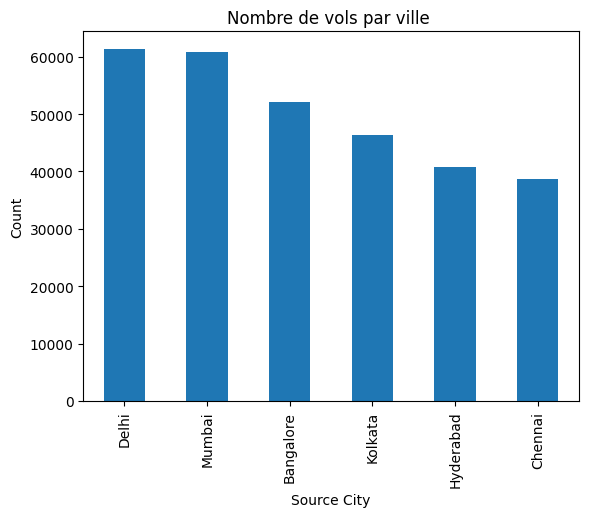

In [55]:
#  Variables discrete
df["source_city"].value_counts().plot(kind="bar")
plt.title("Nombre de vols par ville ")
plt.xlabel("Source City")
plt.ylabel("Count")
plt.show()


In [56]:
df["destination_city"].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

### Variables numériques 

In [57]:
df["duration"].describe()

count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64

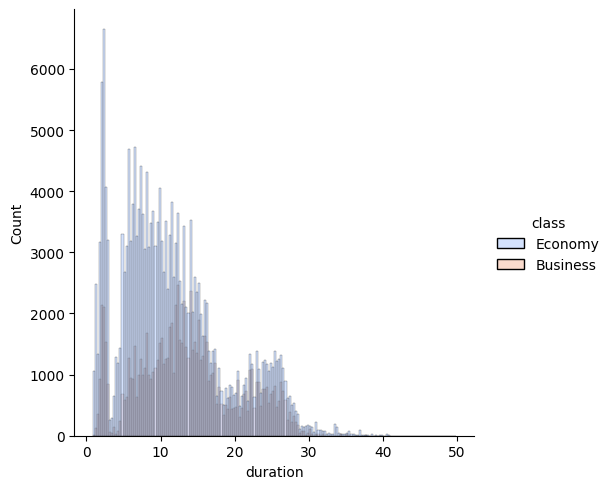

In [58]:

sns.displot(data=df, x="duration", hue="class", palette="coolwarm")


#  Statistiques descriptives de la variable duration

| Statistique | Valeur | Interprétation |
|-------------|--------|----------------|
| count | 300153 | Nombre total de vols dans le dataset |
| mean | 12.22 | Durée moyenne des vols (~12 heures) |
| std | 7.19 | Forte dispersion des durées |
| min | 0.83 | Vol très court (~50 minutes) |
| 25% | 6.83 | 25% des vols durent moins de 7h |
| 50% | 11.25 | Médiane des durées |
| 75% | 16.17 | 75% des vols durent moins de 16h |
| max | 49.83 | Vol très long (~2 jours) |

In [59]:
df["price"].describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

| Statistiques | Valeur | Interprétation | 
|------------|----------|----------------| 
| Moyenne | 20889.66 | Moyenne élevée, influence par de grandes valeurs | 
| Norme | 22697.77 | Forte dispersion des données | 
| Min | 1105.00 | Valeur minimale faible | 
| 25% | 4783.00 | 25% des valeurs sont Inférieures à 4783 | 
| 50 % (médiane)| 7425.00 | Médiane bien inférieure à la moyenne → asymétrie à droite | 
| 75% | 42521.00 | 75% des valeurs sont Inférieures à 42521 (intervalle large) | 
| Max | 123071.00| Valeur très élevée → présence possible d'outlie

<Axes: xlabel='price'>

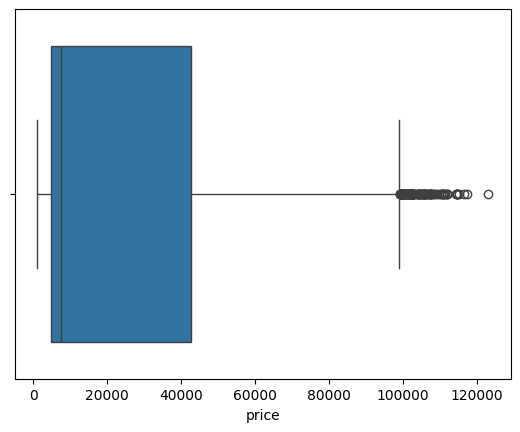

In [60]:
sns.boxplot(data=df,x="price")

### 4 - Analyse multivariée


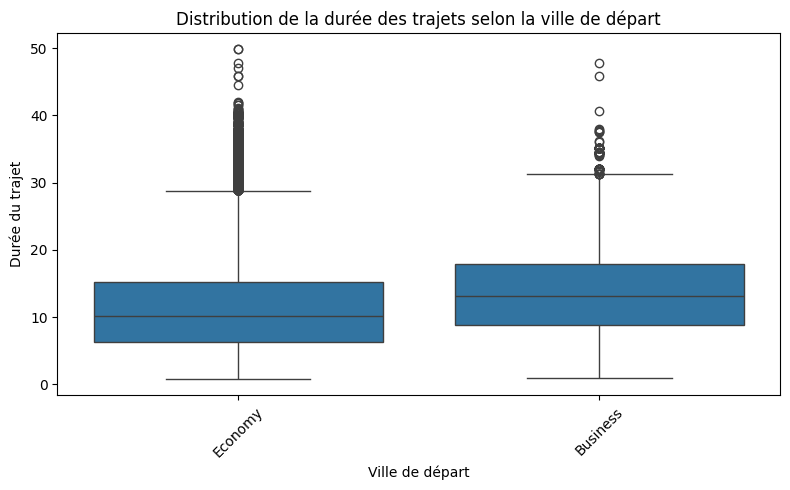

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="class", y="duration",)
plt.xlabel("class")
plt.ylabel("Durée du trajet")
plt.title("Distribution de la durée des trajets selon la ville de départ")
plt.xticks(rotation=45)  # pour mieux lire les villes si elles sont nombreuses
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Relation entre le nombre de jours restants et le prix')

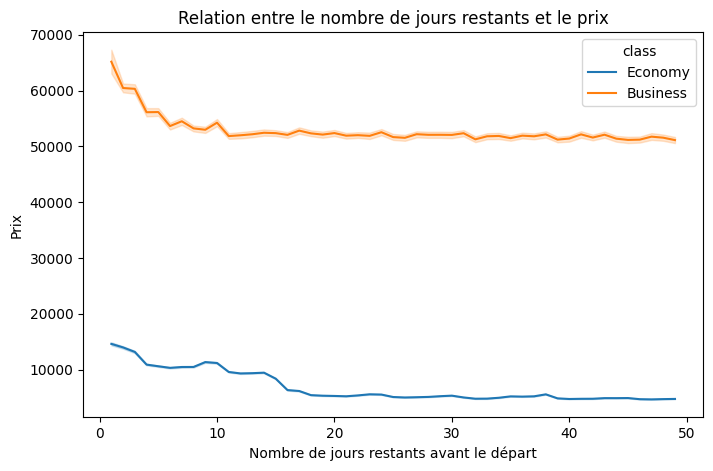

In [66]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df,x="days_left",y="price",hue="class")
plt.xlabel("Nombre de jours restants avant le départ")
plt.ylabel("Prix")
plt.title("Relation entre le nombre de jours restants et le prix")

In [ ]:
pd.crosstab(df["class"],df["departure_time"])
#sns.heatmap(pd.crosstab(df["class"],df["departure_time"]),annot=True)

departure_time,Afternoon,Early_Morning,Evening,Late_Night,Morning,Night
class,,,,,,
Business,12549,20102,20895,138,22325,17478
Economy,35245,46688,44207,1168,48821,30537
